In [8]:
#!/usr/bin/env python3
"""
run_analysis.py — FLARE Single Model Full Analysis (v2.2)
==========================================================
Tek FLARE modeli + LR + RF/XGBoost.
Aynı FLARE modeli her analizde kullanılır.
Tüm hesaplama helpers.py'de.

KULLANIM:
  1. Aşağıdaki parametreleri değiştir
  2. python run_analysis.py
"""

import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from datasets import load_dataset
from flare import FLARE

from helpers import (
    # Eğitim
    fit_competitor_lr,
    fit_competitor_rf,
    compute_metrics,
    # Model özetleri
    print_model_summary,
    lr_coefficients_full,
    lr_vs_flare_table,
    beta_equiv_summary,
    # Öznitelik önem
    raw_coefficients_comparison,
    feature_importance_ranking,
    # Etkileşimler
    run_interaction_analysis,
    beta_equiv_by_group,
    # Hasta profili
    patient_risk_profile,
    print_patient_risk_report,
    rff_attribution_patient,
    # Hasta Hessian
    compute_patient_hessians_with_ci,
    print_patient_hessians_with_ci,
    global_vs_patient_interactions,
    unique_patient_interactions,
    # Kalibrasyon & validasyon
    residuals_summary,
    binary_posterior_coverage,
    patient_posterior_plausibility,
    print_coverage_report,
    # Görselleştirme verileri
    calibration_plot_data,
    residuals_plot_data,
    roc_curve_data,
    pr_curve_data,
    # Synthetic
    true_beta_comparison,
)

EPS = 1e-10

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False


# ═══════════════════════════════════════════════════════════════
#  KULLANICI PARAMETRELERİ
# ═══════════════════════════════════════════════════════════════
DATASET   = 'flchain'
M         = 237
L2        = 0.1
SIGMA     = None
SEED      = 42
TEST_SIZE = 0.20


# ═══════════════════════════════════════════════════════════════
#  ANA ANALİZ
# ═══════════════════════════════════════════════════════════════

def main():

    # ──────────────────────────────────────────────────────────
    # 1. VERİ YÜKLE + SPLIT
    # ──────────────────────────────────────────────────────────
    X, y, meta = load_dataset(DATASET, normalize=True, seed=SEED)
    feature_names = meta.get(
        'feature_names',
        [f'x{i+1}' for i in range(X.shape[1])])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        stratify=y, random_state=SEED)

    d = X_train.shape[1]

    print(f"\n  {'═' * 75}")
    print(f"  FLARE — TEK MODEL ANALİZ")
    print(f"  {'═' * 75}")
    print(f"  Veri       : {meta['name']}")
    print(f"  n_total    : {meta['n_final']}")
    print(f"  d          : {meta['d_final']}")
    print(f"  pos_rate   : {meta['pos_rate']:.1%}")
    print(f"  n_train    : {len(y_train)}")
    print(f"  n_test     : {len(y_test)}")
    print(f"  m          : {M}")
    print(f"  λ (l2)     : {L2}")
    print(f"  σ          : "
          f"{'otomatik' if SIGMA is None else f'{SIGMA:.4f}'}")
    print(f"  seed       : {SEED}")

    # ──────────────────────────────────────────────────────────
    # 2. FLARE EĞİT
    # ──────────────────────────────────────────────────────────
    print(f"\n  {'─' * 75}")
    print(f"  FLARE Eğitimi")
    print(f"  {'─' * 75}")

    flare = FLARE(m=M, l2=L2, seed=SEED)
    flare.fit(X_train, y_train, sigma=SIGMA)

    flare_probs = flare.predict_proba(X_test)[:, 1]
    flare_preds = flare.predict(X_test, threshold=0.5)
    flare_m = compute_metrics(y_test, flare_probs, flare_preds)

    print(f"  σ (seçilen): {flare.sigma_:.6f}")
    print(f"  AUC        : {flare_m['AUC']:.4f}")
    print(f"  PR-AUC     : {flare_m['PR-AUC']:.4f}")
    print(f"  F1         : {flare_m['F1']:.4f}")
    print(f"  Accuracy   : {flare_m['ACC']:.4f}")
    print(f"  MCC        : {flare_m['MCC']:.4f}")

    # ──────────────────────────────────────────────────────────
    # 3. LR EĞİT
    # ──────────────────────────────────────────────────────────
    print(f"\n  {'─' * 75}")
    print(f"  LR Eğitimi (Wald karşılaştırma için)")
    print(f"  {'─' * 75}")

    lr_model = fit_competitor_lr(X_train, y_train, C=1.0)
    lr_probs = lr_model.predict_proba(X_test)[:, 1]
    lr_m = compute_metrics(y_test, lr_probs,
                           lr_model.predict(X_test))
    print(f"  LR AUC     : {lr_m['AUC']:.4f}")

    # ──────────────────────────────────────────────────────────
    # 4. MODEL ÖZETİ
    # ──────────────────────────────────────────────────────────
    summary = print_model_summary(flare, X_test, y_test)

    # ──────────────────────────────────────────────────────────
    # 5. β_equiv TABLOSU
    # ──────────────────────────────────────────────────────────
    beq = beta_equiv_summary(flare, feature_names)

    # ──────────────────────────────────────────────────────────
    # 6. LR KATSAYILARI + KARŞILAŞTIRMA
    # ──────────────────────────────────────────────────────────
    lr_res = lr_coefficients_full(
        lr_model, X_train, y_train, feature_names)
    lr_vs_flare_table(lr_res, beq, feature_names)

    # ──────────────────────────────────────────────────────────
    # 7. ÖZNİTELİK ÖNEMİ: FLARE vs LR vs RF vs XGBoost
    # ──────────────────────────────────────────────────────────
    print(f"\n  {'─' * 75}")
    print(f"  Öznitelik Önemi — Rakip Eğitimi")
    print(f"  {'─' * 75}")

    rf_model = fit_competitor_rf(X_train, y_train,
                                 n_estimators=500, seed=SEED)
    print(f"  RF ✓")

    xgb_model = None
    if HAS_XGB:
        xgb_model = XGBClassifier(
            n_estimators=200, max_depth=6,
            learning_rate=0.1, eval_metric='logloss',
            random_state=SEED, verbosity=0)
        xgb_model.fit(X_train, y_train)
        print(f"  XGBoost ✓")
    else:
        print(f"  XGBoost ATLANDI (pip install xgboost)")

    # Tablo A: Ham katsayılar
    raw_coefficients_comparison(flare, lr_model, feature_names)

    # Tablo B: Normalize sıralama + Spearman
    feature_importance_ranking(
        flare, lr_model=lr_model, rf_model=rf_model,
        xgb_model=xgb_model, feature_names=feature_names)

    # ──────────────────────────────────────────────────────────
    # 8. GLOBAL ETKİLEŞİM TESTLERİ
    # ──────────────────────────────────────────────────────────
    interactions = run_interaction_analysis(
        flare, X_train, feature_names,
        report_threshold=0.2, top_n_ref=3)

    # ──────────────────────────────────────────────────────────
    # 9. RİSK GRUPLARI — β_equiv by group
    # ──────────────────────────────────────────────────────────
    beta_equiv_by_group(
        flare, X_test, y_test, feature_names, n_groups=3)

    # ──────────────────────────────────────────────────────────
    # 10. HASTA SEÇİMİ — 4 BELİRSİZLİK KATEGORİSİ + YÜKSEK RİSKLİ CC
    # ──────────────────────────────────────────────────────────

    # CI hesapla
    ci_result = flare.predict_ci(X_test)
    ci_lo = ci_result['ci_lo']
    ci_hi = ci_result['ci_hi']
    se_all = ci_result['se_eta']

    # 4 kategori
    ci_excludes_05 = (ci_lo > 0.5) | (ci_hi < 0.5)
    prediction = (flare_probs >= 0.5).astype(int)
    correct = (prediction == y_test.astype(int))

    cat_cc = np.where(ci_excludes_05 & correct)[0]
    cat_cw = np.where(ci_excludes_05 & ~correct)[0]
    cat_uc = np.where(~ci_excludes_05 & correct)[0]
    cat_uw = np.where(~ci_excludes_05 & ~correct)[0]

    print(f"\n  Kategori havuzları:")
    print(f"    CC: {len(cat_cc)}")
    print(f"    CW: {len(cat_cw)}")
    print(f"    UC: {len(cat_uc)}")
    print(f"    UW: {len(cat_uw)}")

    # CC-Low: düşük riskli, SE yüksek (p̂ < 0.2)
    idx_cc_low = None
    if len(cat_cc) > 0:
        low_cc = cat_cc[flare_probs[cat_cc] < 0.2]
        if len(low_cc) > 0:
            idx_cc_low = low_cc[np.argmax(se_all[low_cc])]

    # CC-High: yüksek riskli, SE yüksek (p̂ > 0.8)
    idx_cc_high = None
    if len(cat_cc) > 0:
        high_cc = cat_cc[flare_probs[cat_cc] > 0.8]
        if len(high_cc) > 0:
            idx_cc_high = high_cc[np.argmax(se_all[high_cc])]

    # CW: p̂ uzak 0.5 ama yanlış, SE düşük (tehlikeli)
    idx_cw = None
    if len(cat_cw) > 0:
        idx_cw = cat_cw[np.argmin(se_all[cat_cw])]

    # UC: p̂ ≈ 0.5'e en yakın
    idx_uc = None
    if len(cat_uc) > 0:
        idx_uc = cat_uc[np.argmin(np.abs(flare_probs[cat_uc] - 0.5))]

    # UW: p̂ ≈ 0.5'e en yakın ama yanlış
    idx_uw = None
    if len(cat_uw) > 0:
        idx_uw = cat_uw[np.argmin(np.abs(flare_probs[cat_uw] - 0.5))]

    selected = [idx for idx in [idx_cc_low, idx_cc_high, idx_cw, idx_uc, idx_uw]
                if idx is not None]

    # Kategori bilgilerini sakla
    patient_categories = {}
    label_map = {
        idx_cc_low: 'CC-Low',
        idx_cc_high: 'CC-High',
        idx_cw: 'CW',
        idx_uc: 'UC',
        idx_uw: 'UW',
    }
    for idx, label in label_map.items():
        if idx is not None:
            patient_categories[idx] = label

    # Yazdır
    print(f"\n  {'─' * 75}")
    print(f"  Seçilen Hastalar (5 Kategori)")
    print(f"  {'─' * 75}")
    print(f"  {'Kategori':<12} {'İndeks':<10} {'p̂':<10} "
          f"{'SE(η)':<10} {'95% CI':<24} {'Doğru':<8} {'Label'}")
    print(f"  {'─' * 75}")
    for idx in selected:
        cat = patient_categories[idx]
        ci_str = f"[{ci_lo[idx]:.4f}, {ci_hi[idx]:.4f}]"
        print(f"  {cat:<12} {idx:<10} {flare_probs[idx]:.4f}  "
              f"{se_all[idx]:.4f}  {ci_str:<24} "
              f"{'✓' if correct[idx] else '✗':<8} "
              f"{int(y_test[idx])}")

    se_vals = [se_all[idx] for idx in selected]
    if len(se_vals) >= 2:
        print(f"\n  SE(η) aralığı  : {min(se_vals):.4f} – "
              f"{max(se_vals):.4f}")
        print(f"  SE(η) oranı    : "
              f"{max(se_vals)/max(min(se_vals), EPS):.2f}×")
    # ──────────────────────────────────────────────────────────
    # 11. HASTA RİSK PROFİLLERİ (4 kategori)
    # ──────────────────────────────────────────────────────────
    for idx in selected:
        label = patient_categories[idx]
        print(f"\n  {'━' * 50}")
        print(f"  Hasta #{idx} — Kategori: {label}")
        print(f"  {'━' * 50}")
        profile = patient_risk_profile(
            flare, X_test, feature_names, idx)
        print_patient_risk_report(profile)

    # ──────────────────────────────────────────────────────────
    # 12. ORF-ATTRIBUTION (4 hasta)
    # ──────────────────────────────────────────────────────────
    for idx in selected:
        rff_attribution_patient(
            flare, X_test, feature_names, idx)

    # ──────────────────────────────────────────────────────────
    # 13. HASTA BAZLI HESSIAN ETKİLEŞİMLERİ
    # ──────────────────────────────────────────────────────────
    hessians_ci, hessians = compute_patient_hessians_with_ci(
        flare, X_test, feature_names, selected, top_n=10)
    print_patient_hessians_with_ci(hessians_ci, flare_probs)

    # ──────────────────────────────────────────────────────────
    # 14. GLOBAL vs HASTA BAZLI KARŞILAŞTIRMA
    # ──────────────────────────────────────────────────────────
    comp_table, H_global = global_vs_patient_interactions(
        flare, X_train, feature_names, selected, hessians)

    # ──────────────────────────────────────────────────────────
    # 15. BENZERSİZ HASTA ETKİLEŞİMLERİ
    # ──────────────────────────────────────────────────────────
    unique_patient_interactions(
        flare, X_train, X_test, feature_names, selected,
        hessians, H_global=H_global, threshold=2.0)

    # ──────────────────────────────────────────────────────────
    # 16. RESİDUAL ANALİZ
    # ──────────────────────────────────────────────────────────
    resid = residuals_summary(flare, X_test, y_test)

    # ──────────────────────────────────────────────────────────
    # 17. POSTERIOR COVERAGE
    # ──────────────────────────────────────────────────────────
    coverage = binary_posterior_coverage(
        flare, X_test, y_test, method='equal_frequency')
    print_coverage_report(coverage)

    # ──────────────────────────────────────────────────────────
    # 18. HASTA OLASI LİK SINIFLANDIRMASI
    # ──────────────────────────────────────────────────────────
    plaus = patient_posterior_plausibility(flare, X_test, y_test)
    print(f"\n  Hasta Olasılık Sınıflandırması:")
    for cat in [1, 2, 3, 4]:
        print(f"    {plaus['labels'][cat]}: "
              f"{plaus['counts'][cat]} "
              f"({plaus['rates'][cat]:.1%})")

    # ──────────────────────────────────────────────────────────
    # 19. TRUE BETA (sentetik veri ise)
    # ──────────────────────────────────────────────────────────
    if 'true_weights' in meta:
        true_beta_comparison(
            meta, flare, lr_model, feature_names)

    # ──────────────────────────────────────────────────────────
    # 20. GÖRSELLEŞTİRME VERİLERİ
    # ──────────────────────────────────────────────────────────
    roc_data = roc_curve_data(flare, X_test, y_test)
    pr_data = pr_curve_data(flare, X_test, y_test)
    cal_data = calibration_plot_data(flare, X_test, y_test)
    resid_data = residuals_plot_data(flare, X_test, y_test)

    print(f"\n  Görselleştirme verileri hazır:")
    print(f"    ROC AUC    = {roc_data['auc']:.4f}")
    print(f"    PR  AP     = {pr_data['ap']:.4f}")
    print(f"    Brier      = {cal_data['brier']:.4f}")
    print(f"    ECE        = {cal_data['ece']:.4f}")

    # ──────────────────────────────────────────────────────────
    # SONUÇ
    # ──────────────────────────────────────────────────────────
    print(f"\n  {'═' * 75}")
    print(f"  ANALİZ TAMAMLANDI")
    print(f"  {'═' * 75}")

    return {
        'flare': flare,
        'lr_model': lr_model,
        'rf_model': rf_model,
        'xgb_model': xgb_model,
        'lr_res': lr_res,
        'beq': beq,
        'interactions': interactions,
        'hessians_ci': hessians_ci,
        'hessians': hessians,
        'H_global': H_global,
        'selected': selected,
        'patient_categories': patient_categories,
        'residuals': resid,
        'coverage': coverage,
        'plausibility': plaus,
        'summary': summary,
        'X_train': X_train, 'y_train': y_train,
        'X_test': X_test, 'y_test': y_test,
        'feature_names': feature_names,
        'meta': meta,
        'roc_data': roc_data,
        'pr_data': pr_data,
        'cal_data': cal_data,
        'resid_data': resid_data,
    }


if __name__ == '__main__':
    result = main()


  ═══════════════════════════════════════════════════════════════════════════
  FLARE — TEK MODEL ANALİZ
  ═══════════════════════════════════════════════════════════════════════════
  Veri       : FLCHAIN (Mortality)
  n_total    : 7816
  d          : 6
  pos_rate   : 27.8%
  n_train    : 6252
  n_test     : 1564
  m          : 237
  λ (l2)     : 0.1
  σ          : otomatik
  seed       : 42

  ───────────────────────────────────────────────────────────────────────────
  FLARE Eğitimi
  ───────────────────────────────────────────────────────────────────────────
  σ (seçilen): 2.361942
  AUC        : 0.8557
  PR-AUC     : 0.7517
  F1         : 0.6160
  Accuracy   : 0.8223
  MCC        : 0.5237

  ───────────────────────────────────────────────────────────────────────────
  LR Eğitimi (Wald karşılaştırma için)
  ───────────────────────────────────────────────────────────────────────────
  LR AUC     : 0.8544

  FLARE MODEL SUMMARY
  Samples        = 1564
  Features (d)   = 6
  Classes 

  FLARE L+NL hesaplanıyor...
  Shape: (1564, 6)
  Gap median: 1.45%
  KernelSHAP hesaplanıyor (1564 hasta)...


  0%|          | 0/1564 [00:00<?, ?it/s]

  Shape: (1564, 6)

  ════════════════════════════════════════════════════════════
  KERNELSHAP vs FLARE L+NL
  ════════════════════════════════════════════════════════════
  Global Spearman : ρ=1.000, p=0.0000
  Hasta median ρ  : 0.829
  ρ > 0.9         : 546 (34.9%)

  ────────────────────────────────────────────────────────────
  Dependence Plots
  ────────────────────────────────────────────────────────────


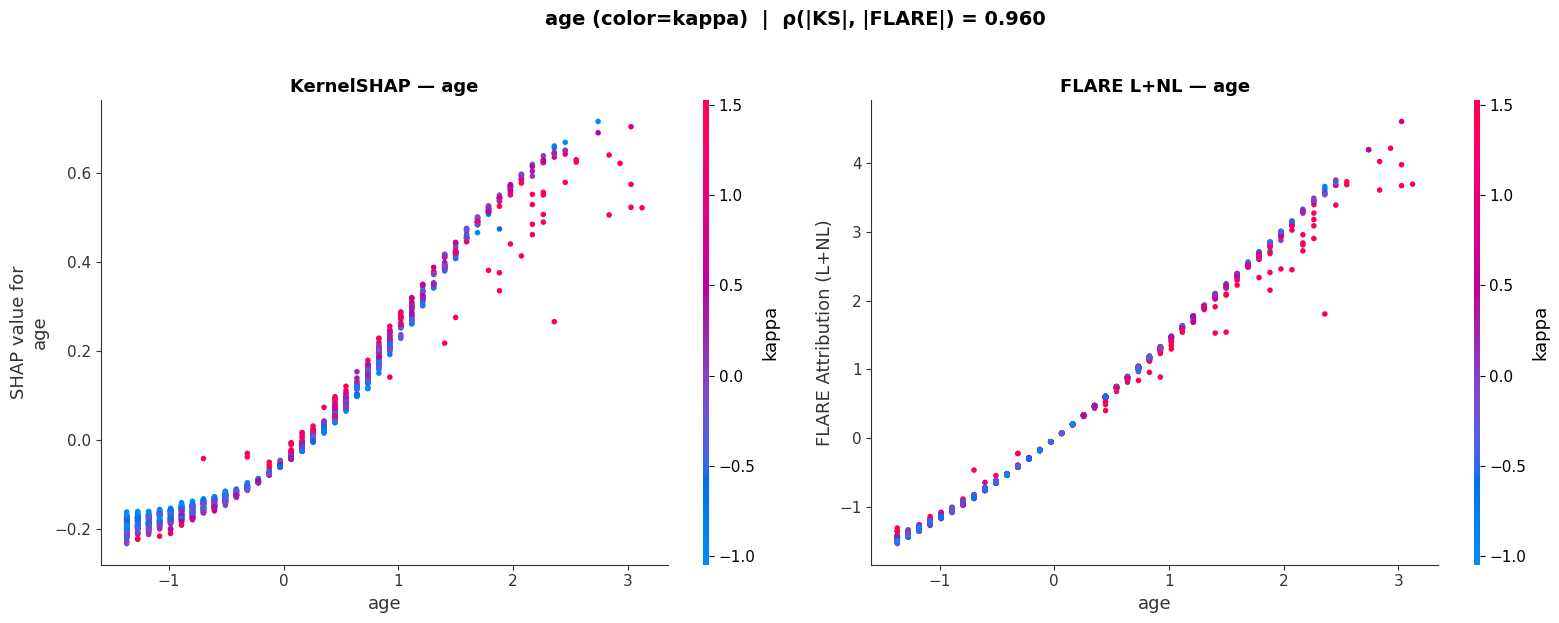

    ✓ age


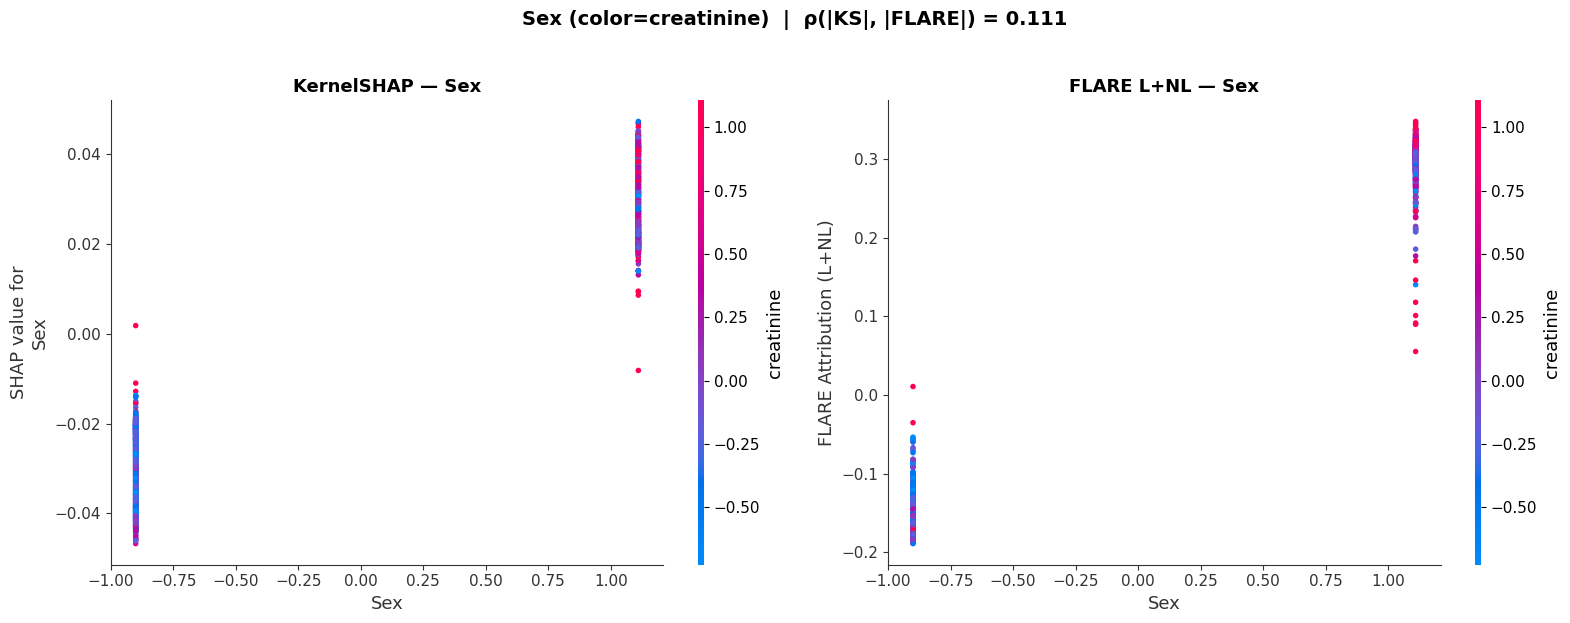

    ✓ Sex


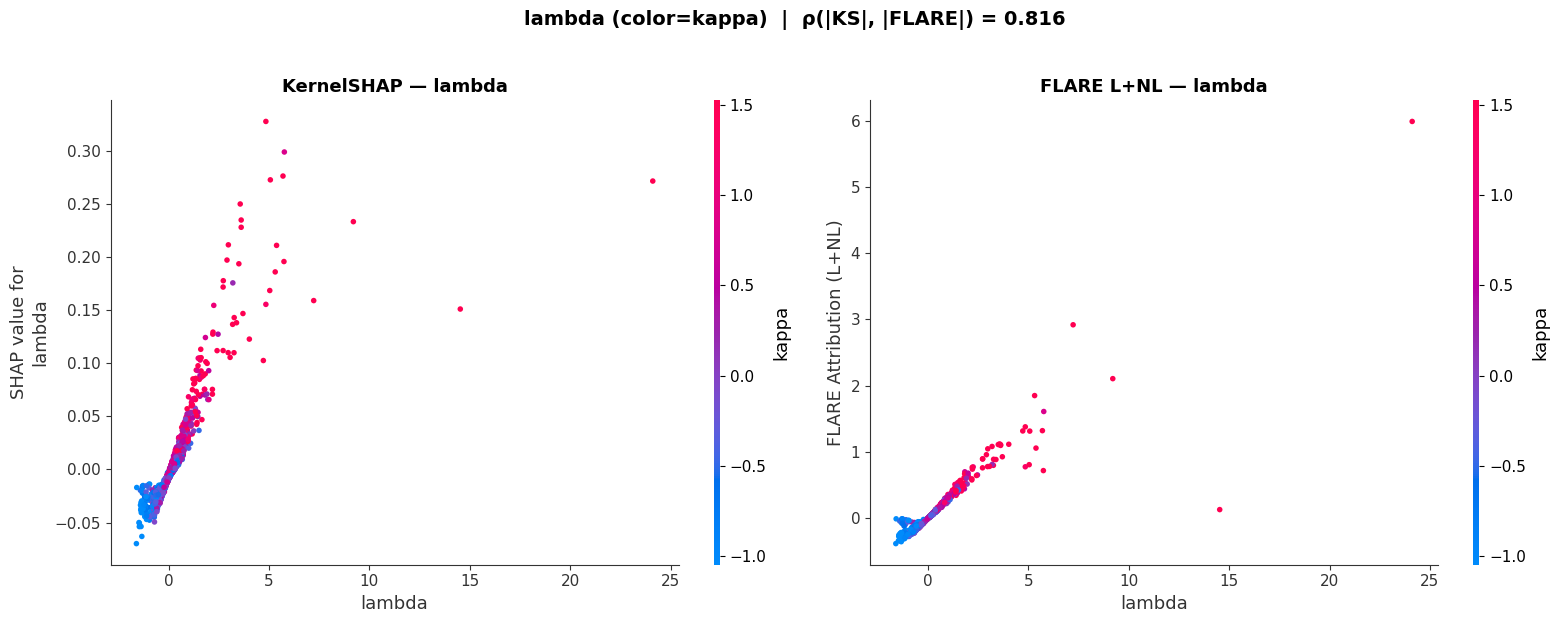

    ✓ lambda


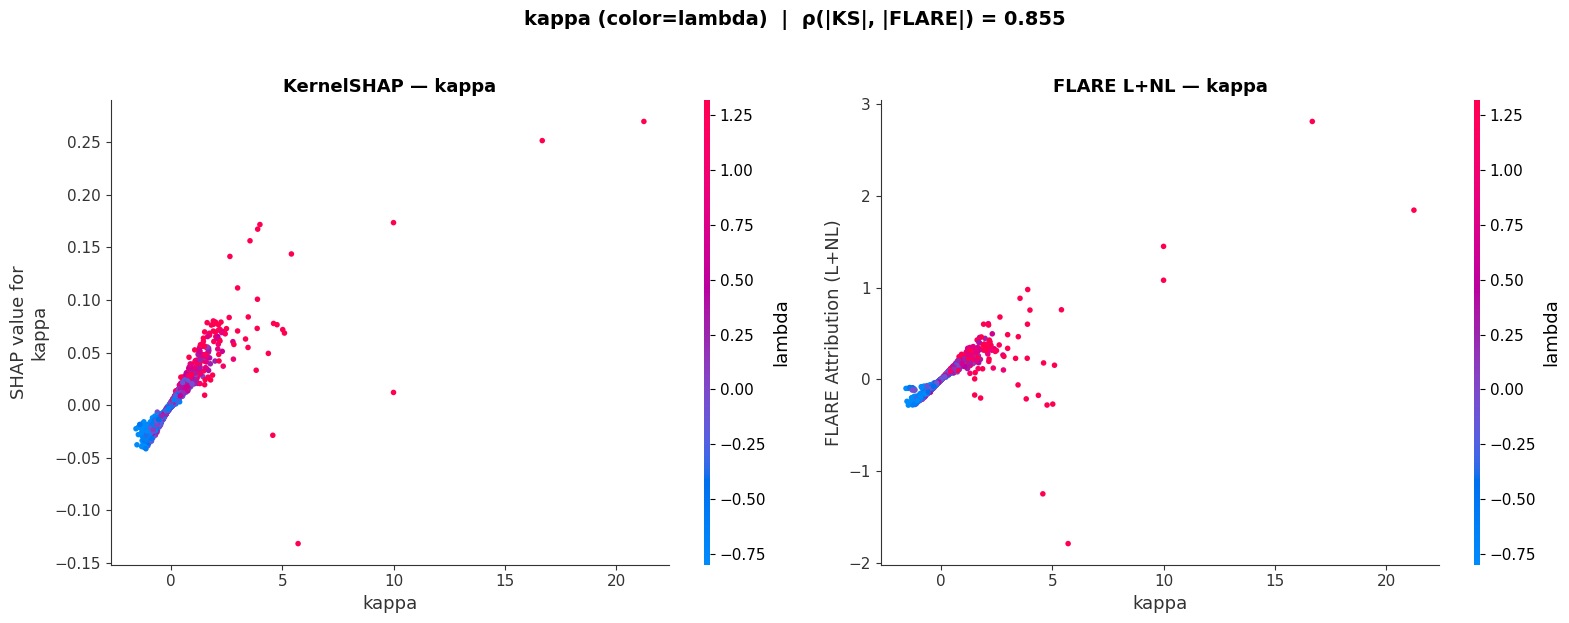

    ✓ kappa


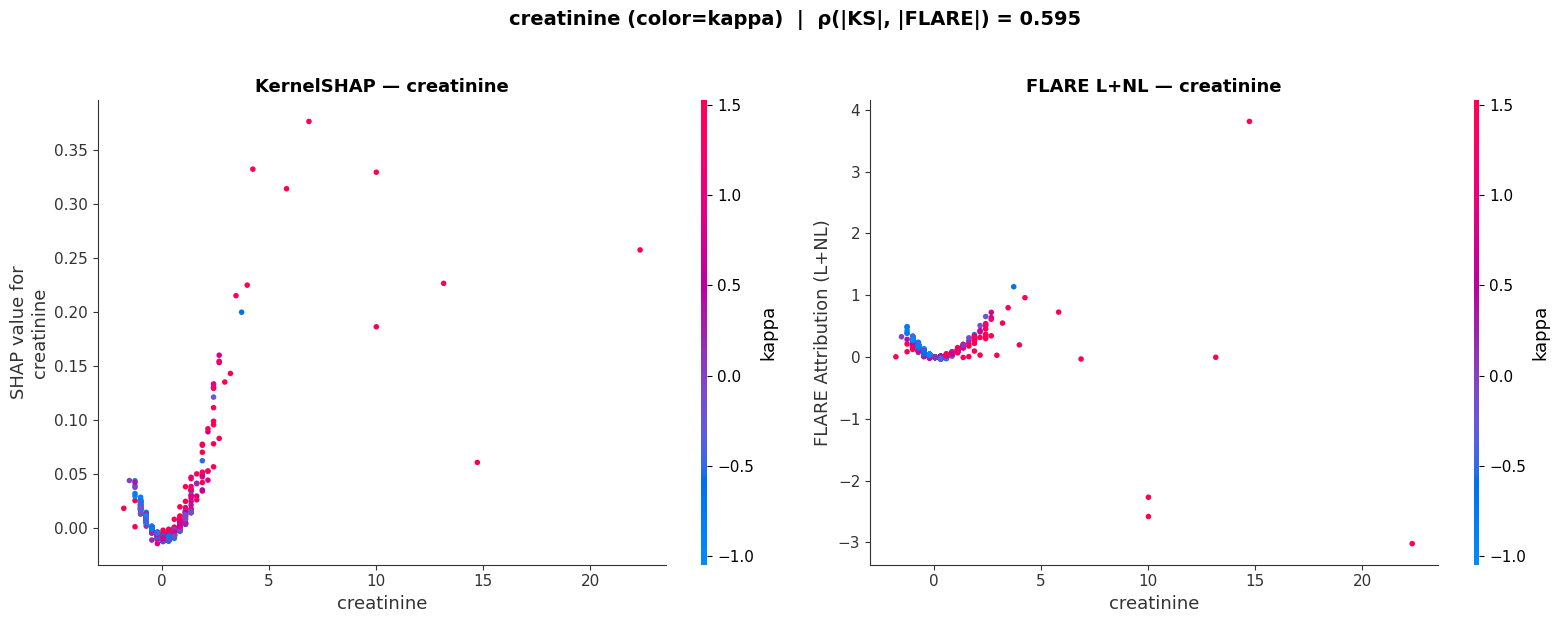

    ✓ creatinine


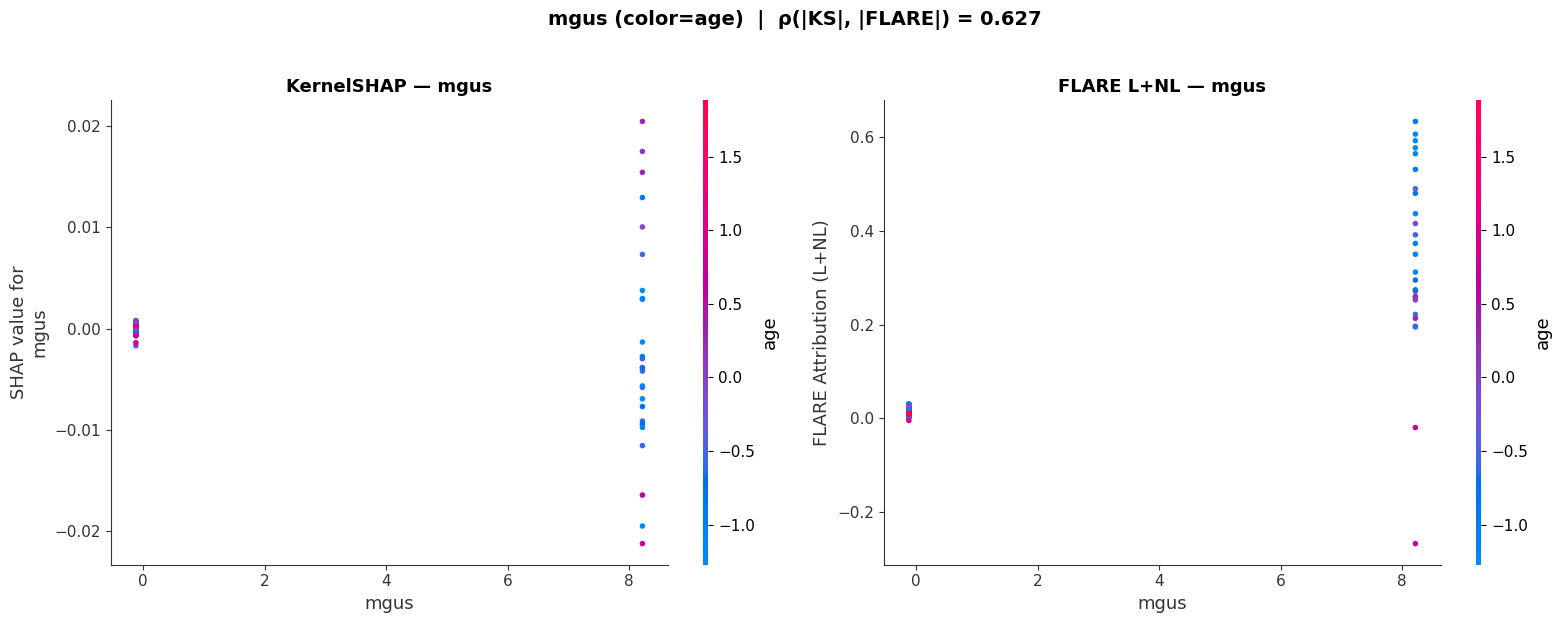

    ✓ mgus


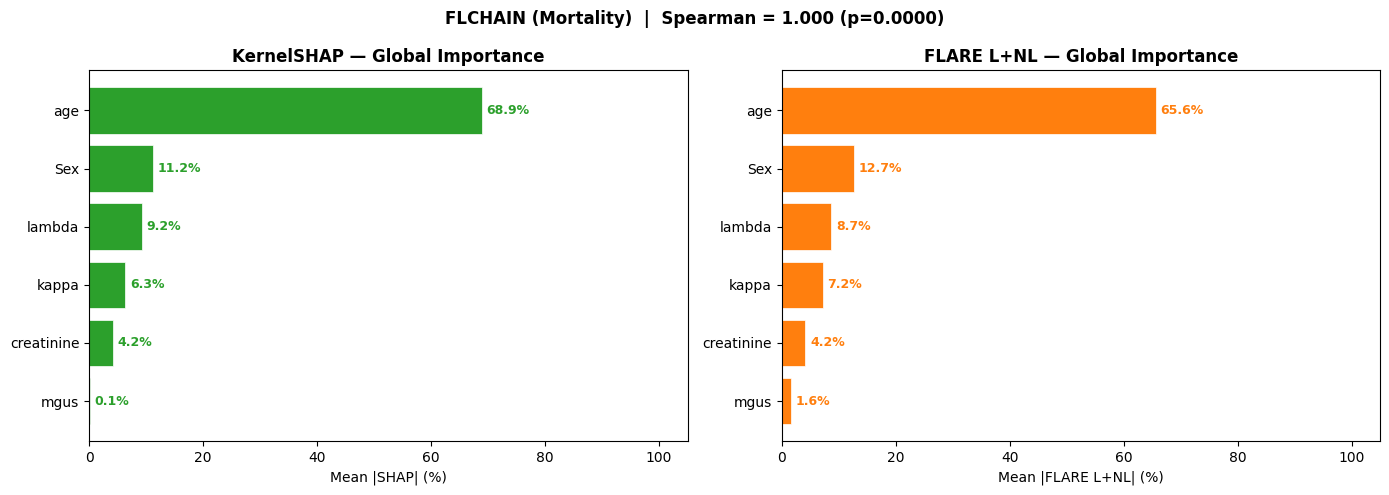

    ✓ Global Importance


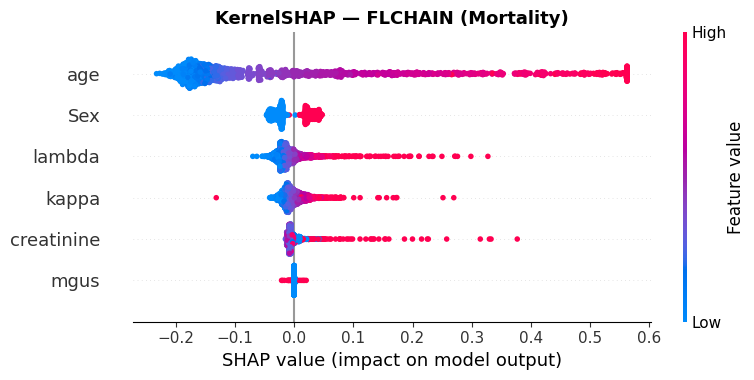

    ✓ Beeswarm — KernelSHAP


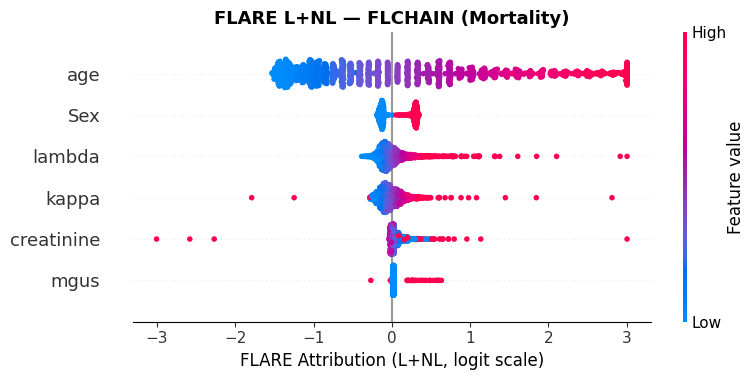

    ✓ Beeswarm — FLARE L+NL


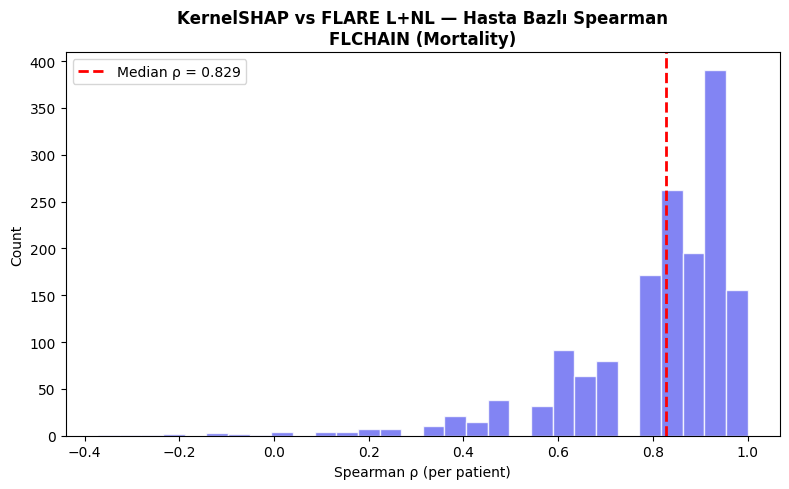

    ✓ Spearman Histogram

  ════════════════════════════════════════════════════════════
  ÖZET
  ════════════════════════════════════════════════════════════
  Global Spearman  : ρ = 1.000
  Hasta median ρ   : 0.829
  ρ > 0.9          : 546/1564 (34.9%)
  Gap median       : 1.45%
  σ                : 2.3619
  ════════════════════════════════════════════════════════════


In [9]:
# ═══════════════════════════════════════════════════════════════
#  DEPENDENCE: KernelSHAP vs FLARE L+NL — TEK HÜCRE
#  run_analysis.py'den SONRA çalıştır (result dict hazır)
# ═══════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import shap
from scipy.stats import spearmanr
from helpers import rff_attribution_bulk

flare         = result['flare']
X_train       = result['X_train']
X_test        = result['X_test']
feature_names = result['feature_names']
meta          = result['meta']

d = len(feature_names)

# ═══════════════════════════════════════════════════════════════
# 1. FLARE L+NL ATTRIBUTION
# ═══════════════════════════════════════════════════════════════
print(f"  FLARE L+NL hesaplanıyor...")
x_bar = X_train.mean(axis=0, keepdims=True)
bulk = rff_attribution_bulk(flare, X_test, x_bar)
flare_attr = bulk['total_per_feature']
print(f"  Shape: {flare_attr.shape}")

sig_mask = np.abs(bulk['eta_diff']) > 0.1
gaps = bulk['gap_pct'][sig_mask]
print(f"  Gap median: {np.nanmedian(gaps):.2f}%")

# ═══════════════════════════════════════════════════════════════
# 2. KERNELSHAP
# ═══════════════════════════════════════════════════════════════
print(f"  KernelSHAP hesaplanıyor ({len(X_test)} hasta)...")

def flare_predict(X_input):
    return flare.predict_proba(X_input)[:, 1]

rng = np.random.default_rng(42)
n_bg = min(100, len(X_train))
bg_idx = rng.choice(len(X_train), n_bg, replace=False)
X_bg = X_train[bg_idx]

explainer = shap.KernelExplainer(flare_predict, X_bg)
shap_orf = explainer.shap_values(X_test, nsamples=200)
print(f"  Shape: {shap_orf.shape}")

# ═══════════════════════════════════════════════════════════════
# 3. GLOBAL KARŞILAŞTIRMA
# ═══════════════════════════════════════════════════════════════
# Ham mean |attribution| değerleri
global_shap_raw  = np.mean(np.abs(shap_orf), axis=0)
global_flare_raw = np.mean(np.abs(flare_attr), axis=0)

# Yüzde normalizasyonu: kendi toplamlarına göre
global_shap  = global_shap_raw / global_shap_raw.sum() * 100
global_flare = global_flare_raw / global_flare_raw.sum() * 100

rho_global, p_global = spearmanr(global_shap, global_flare)

patient_rhos = []
for i in range(len(X_test)):
    r, _ = spearmanr(np.abs(shap_orf[i]), np.abs(flare_attr[i]))
    if np.isfinite(r):
        patient_rhos.append(r)
patient_rhos = np.array(patient_rhos)

print(f"\n  {'═' * 60}")
print(f"  KERNELSHAP vs FLARE L+NL")
print(f"  {'═' * 60}")
print(f"  Global Spearman : ρ={rho_global:.3f}, p={p_global:.4f}")
print(f"  Hasta median ρ  : {np.median(patient_rhos):.3f}")
print(f"  ρ > 0.9         : {(patient_rhos > 0.9).sum()}"
      f" ({(patient_rhos > 0.9).mean():.1%})")

# ═══════════════════════════════════════════════════════════════
# 4. DEPENDENCE — TÜM ÖZNİTELİKLER
# ═══════════════════════════════════════════════════════════════
print(f"\n  {'─' * 60}")
print(f"  Dependence Plots")
print(f"  {'─' * 60}")

mean_abs = np.mean(np.abs(flare_attr), axis=0)
top4 = np.argsort(-mean_abs)[:min(6, d)]

for j in top4:
    fname = feature_names[j]

    best_corr = 0
    best_k = None
    for k in range(d):
        if k == j:
            continue
        c = np.corrcoef(X_test[:, k], flare_attr[:, j])[0, 1]
        if abs(c) > abs(best_corr):
            best_corr = c
            best_k = k

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    shap.dependence_plot(
        j, shap_orf, X_test,
        feature_names=feature_names,
        interaction_index=best_k,
        ax=ax, show=False)
    ax.set_title(f'KernelSHAP — {fname}',
                 fontsize=13, fontweight='bold')

    ax = axes[1]
    shap.dependence_plot(
        j, flare_attr, X_test,
        feature_names=feature_names,
        interaction_index=best_k,
        ax=ax, show=False)
    ax.set_title(f'FLARE L+NL — {fname}',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('FLARE Attribution (L+NL)')
    ax.set_xlabel(feature_names[j])

    rho_j = np.corrcoef(
        np.abs(shap_orf[:, j]),
        np.abs(flare_attr[:, j]))[0, 1]

    plt.suptitle(
        f'{fname} (color={feature_names[best_k]})  |  '
        f'ρ(|KS|, |FLARE|) = {rho_j:.3f}',
        fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()
    print(f"    ✓ {fname}")

# ═══════════════════════════════════════════════════════════════
# 5. GLOBAL IMPORTANCE BAR
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order_s = np.argsort(global_shap)

ax = axes[0]
bars = ax.barh(range(d), global_shap[order_s],
               color='#2ca02c', edgecolor='white', linewidth=0.5)
ax.set_yticks(range(d))
ax.set_yticklabels([feature_names[i] for i in order_s])
ax.set_xlabel('Mean |SHAP| (%)')
ax.set_title('KernelSHAP — Global Importance',
             fontweight='bold')
ax.set_xlim(0, 105)
for i, (v, bar) in enumerate(zip(global_shap[order_s], bars)):
    ax.text(v + 0.8, i, f'{v:.1f}%', va='center',
            fontsize=9, fontweight='bold', color='#2ca02c')

ax = axes[1]
bars = ax.barh(range(d), global_flare[order_s],
               color='#ff7f0e', edgecolor='white', linewidth=0.5)
ax.set_yticks(range(d))
ax.set_yticklabels([feature_names[i] for i in order_s])
ax.set_xlabel('Mean |FLARE L+NL| (%)')
ax.set_title('FLARE L+NL — Global Importance',
             fontweight='bold')
ax.set_xlim(0, 105)
for i, (v, bar) in enumerate(zip(global_flare[order_s], bars)):
    ax.text(v + 0.8, i, f'{v:.1f}%', va='center',
            fontsize=9, fontweight='bold', color='#ff7f0e')

plt.suptitle(
    f'{meta["name"]}  |  '
    f'Spearman = {rho_global:.3f} (p={p_global:.4f})',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"    ✓ Global Importance")
# ═══════════════════════════════════════════════════════════════
# 6. BEESWARM (DÜZELTİLMİŞ)
# ═══════════════════════════════════════════════════════════════

# Ayrı clip değerleri — kendi ölçeklerinde
shap_clip  = np.clip(shap_orf,
                     -np.percentile(np.abs(shap_orf), 99.5),
                      np.percentile(np.abs(shap_orf), 99.5))

flare_clip = np.clip(flare_attr,
                     -np.percentile(np.abs(flare_attr), 99.5),
                      np.percentile(np.abs(flare_attr), 99.5))

# KernelSHAP beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_clip, X_test,
                  feature_names=feature_names, show=False)
plt.title(f'KernelSHAP — {meta["name"]}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"    ✓ Beeswarm — KernelSHAP")

# FLARE beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(flare_clip, X_test,
                  feature_names=feature_names, show=False)
plt.title(f'FLARE L+NL — {meta["name"]}',
          fontsize=13, fontweight='bold')
# X-axis etiketini değiştir
plt.gca().set_xlabel('FLARE Attribution (L+NL, logit scale)',
                      fontsize=12)
plt.tight_layout()
plt.show()
print(f"    ✓ Beeswarm — FLARE L+NL")

# ═══════════════════════════════════════════════════════════════
# 7. SPEARMAN HISTOGRAM
# ═══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(patient_rhos, bins=30, color='#6366f1',
        edgecolor='white', alpha=0.8)
ax.axvline(np.median(patient_rhos), color='red',
           linestyle='--', linewidth=2,
           label=f'Median ρ = {np.median(patient_rhos):.3f}')
ax.set_xlabel('Spearman ρ (per patient)')
ax.set_ylabel('Count')
ax.set_title(
    f'KernelSHAP vs FLARE L+NL — Hasta Bazlı Spearman\n'
    f'{meta["name"]}',
    fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(f"    ✓ Spearman Histogram")

# ═══════════════════════════════════════════════════════════════
# 8. ÖZET
# ═══════════════════════════════════════════════════════════════
print(f"\n  {'═' * 60}")
print(f"  ÖZET")
print(f"  {'═' * 60}")
print(f"  Global Spearman  : ρ = {rho_global:.3f}")
print(f"  Hasta median ρ   : {np.median(patient_rhos):.3f}")
print(f"  ρ > 0.9          : {(patient_rhos > 0.9).sum()}"
      f"/{len(patient_rhos)}"
      f" ({(patient_rhos > 0.9).mean():.1%})")
print(f"  Gap median       : {np.nanmedian(gaps):.2f}%")
print(f"  σ                : {flare.sigma_:.4f}")
print(f"  {'═' * 60}")


  RFF-Attribution (Simpson) — Patient #38
  η(x) = 3.6530, η(x̄) = -1.5569, Δη = 5.2099
  Var             Attr(L)   Attr(NL)      Total      Dir
  -------------------------------------------------------
  age              3.1274    -1.0482     2.0792        ↑
  kappa            2.1746    -1.9575     0.2171        ↑
  lambda           2.5664    -0.0947     2.4717        ↑
  creatinine      -0.1156     0.2293     0.1137        ↑
  mgus             0.0201     0.0052     0.0253        ↑
  Sex              0.2328    -0.2034     0.0294        ↑
  -------------------------------------------------------
  Sum                                    4.9365
  Δη                                     5.2099
  Gap                                    0.2735  (5.2%)
  Quality                                        ✓ Good

  RFF-Attribution (Simpson) — Patient #330
  η(x) = -2.7225, η(x̄) = -1.5569, Δη = -1.1656
  Var             Attr(L)   Attr(NL)      Total      Dir
  -------------------------------------

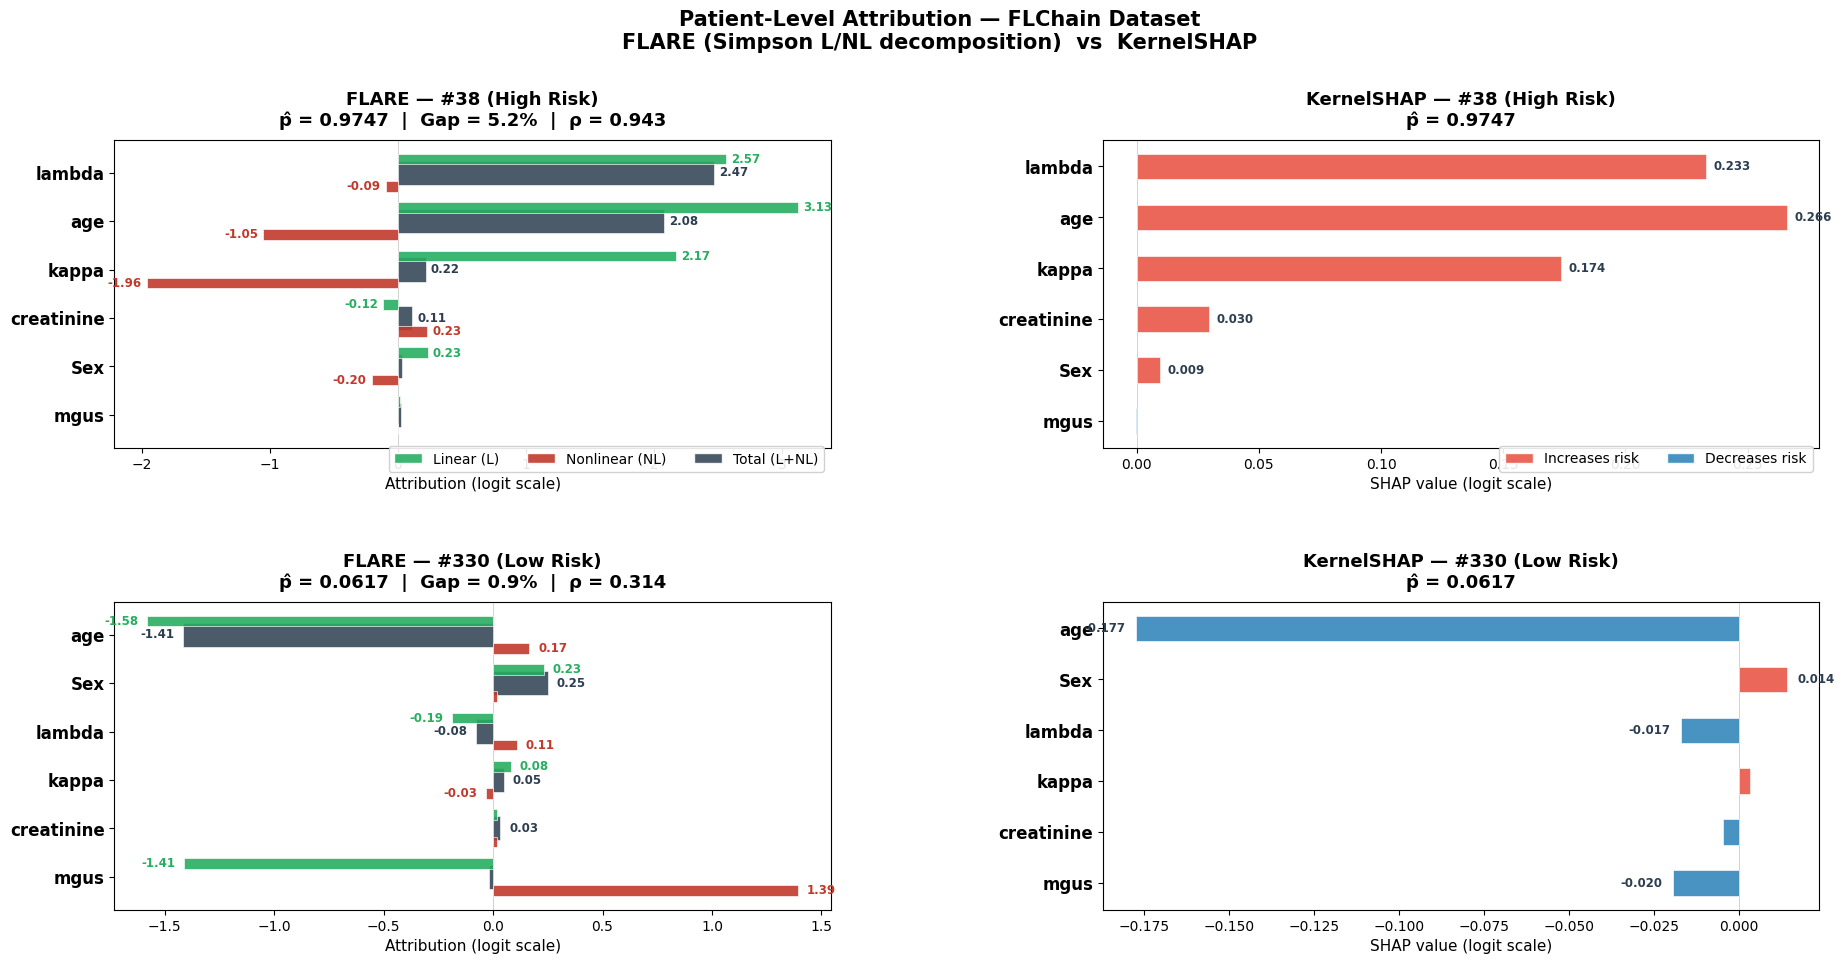

  ✓ Fig. 4 kaydedildi

  SHAP vs ORF-ATTRIBUTION COMPARISON

  RFF-Attribution (Simpson) — Patient #38
  η(x) = 3.6530, η(x̄) = -1.5569, Δη = 5.2099
  Var             Attr(L)   Attr(NL)      Total      Dir
  -------------------------------------------------------
  age              3.1274    -1.0482     2.0792        ↑
  kappa            2.1746    -1.9575     0.2171        ↑
  lambda           2.5664    -0.0947     2.4717        ↑
  creatinine      -0.1156     0.2293     0.1137        ↑
  mgus             0.0201     0.0052     0.0253        ↑
  Sex              0.2328    -0.2034     0.0294        ↑
  -------------------------------------------------------
  Sum                                    4.9365
  Δη                                     5.2099
  Gap                                    0.2735  (5.2%)
  Quality                                        ✓ Good

  ── Patient #38 (High Risk) (p̂=0.9747) ── Gap=5.2% ── ρ=0.943 ──
  Feature            L+NL     SHAP Rank(L+NL) Rank(SHAP)  Di

In [4]:
# ═══════════════════════════════════════════════════════════════
#  FIG. 4 — Patient-Level Attribution (v5)
#  Lacivert bar kalın (SHAP ile aynı), yeşil/kırmızı ince
# ═══════════════════════════════════════════════════════════════

from helpers import rff_attribution_patient
from matplotlib.patches import Patch

patient_specs = [
    {'label': '#38 (High Risk)', 'idx': 38, 'p_hat': 0.9747},
    {'label': '#330 (Low Risk)', 'idx': 330, 'p_hat': 0.0617},
]

fig, axes = plt.subplots(2, 2, figsize=(22, 10),
                          gridspec_kw={'wspace': 0.38, 'hspace': 0.50})

BAR_THIN = 0.22   # yeşil, kırmızı
BAR_THICK = 0.50  # lacivert (SHAP ile aynı)
OFFSET = 0.28     # ince barların kalın bardan uzaklığı

def _add_labels(ax, y_pos, values, color, threshold=0.03):
    for y, v in zip(y_pos, values):
        if abs(v) > threshold:
            off = 0.04 * np.sign(v)
            ax.text(v + off, y, f'{v:.2f}',
                    va='center',
                    ha='left' if v > 0 else 'right',
                    fontsize=8.5, color=color, fontweight='bold')

for row, spec in enumerate(patient_specs):
    idx = spec['idx']

    simp = rff_attribution_patient(flare, X_test, feature_names, idx)
    L_vals     = simp['attr_linear'].flatten()
    NL_vals    = simp['attr_nonlinear'].flatten()
    total_vals = simp['total'].flatten()
    gap_val    = simp['gap_pct']
    shap_vals  = shap_orf[idx]

    order = np.argsort(np.abs(total_vals))[::-1]
    feat  = [feature_names[i] for i in order]
    L_o   = L_vals[order]
    NL_o  = NL_vals[order]
    T_o   = total_vals[order]
    S_o   = shap_vals[order]

    n = len(order)
    y_base = np.arange(n)[::-1]

    # Pozisyonlar: Total ortada (kalın), L üstte, NL altta
    y_T  = y_base
    y_L  = y_base + OFFSET
    y_NL = y_base - OFFSET

    # ═══════════════════════════════════════
    # SOL: FLARE
    # ═══════════════════════════════════════
    ax = axes[row, 0]

    # Önce kalın lacivert (arka planda)
    ax.barh(y_T, T_o, height=BAR_THICK,
            color='#2c3e50', edgecolor='white',
            linewidth=0.5, alpha=0.85, zorder=2)

    # Sonra ince yeşil ve kırmızı (üstte)
    ax.barh(y_L, L_o, height=BAR_THIN,
            color='#27ae60', edgecolor='white',
            linewidth=0.5, alpha=0.90, zorder=3)
    ax.barh(y_NL, NL_o, height=BAR_THIN,
            color='#c0392b', edgecolor='white',
            linewidth=0.5, alpha=0.90, zorder=3)

    # Değer etiketleri
    _add_labels(ax, y_L,  L_o, '#27ae60', threshold=0.03)
    _add_labels(ax, y_NL, NL_o, '#c0392b', threshold=0.03)
    _add_labels(ax, y_T,  T_o,  '#2c3e50', threshold=0.03)

    ax.set_yticks(y_base)
    ax.set_yticklabels(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('Attribution (logit scale)', fontsize=11)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5, zorder=0)

    rho_p, _ = spearmanr(np.abs(shap_vals), np.abs(total_vals))
    ax.set_title(
        f'FLARE — {spec["label"]}\n'
        f'p̂ = {spec["p_hat"]:.4f}  |  Gap = {gap_val:.1f}%  |  '
        f'ρ = {rho_p:.3f}',
        fontsize=13, fontweight='bold', pad=10)

    if row == 0:
        legend_el = [
            Patch(facecolor='#27ae60', edgecolor='white',
                  alpha=0.90, label='Linear (L)'),
            Patch(facecolor='#c0392b', edgecolor='white',
                  alpha=0.90, label='Nonlinear (NL)'),
            Patch(facecolor='#2c3e50', edgecolor='white',
                  alpha=0.85, label='Total (L+NL)'),
        ]
        ax.legend(handles=legend_el, loc='lower right',
                  fontsize=10, framealpha=0.9, ncol=3,
                  bbox_to_anchor=(1.0, -0.10))

    # ═══════════════════════════════════════
    # SAĞ: KernelSHAP
    # ═══════════════════════════════════════
    ax = axes[row, 1]

    colors_shap = ['#e74c3c' if v > 0 else '#2980b9' for v in S_o]

    ax.barh(y_base, S_o, height=BAR_THICK,
            color=colors_shap, edgecolor='white',
            linewidth=0.5, alpha=0.85, zorder=3)

    for y, v in zip(y_base, S_o):
        if abs(v) > 0.005:
            off = 0.003 * np.sign(v)
            ax.text(v + off, y, f'{v:.3f}',
                    va='center',
                    ha='left' if v > 0 else 'right',
                    fontsize=8.5, color='#2c3e50', fontweight='bold')

    ax.set_yticks(y_base)
    ax.set_yticklabels(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('SHAP value (logit scale)', fontsize=11)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5, zorder=0)

    ax.set_title(
        f'KernelSHAP — {spec["label"]}\n'
        f'p̂ = {spec["p_hat"]:.4f}',
        fontsize=13, fontweight='bold', pad=10)

    if row == 0:
        legend_s = [
            Patch(facecolor='#e74c3c', edgecolor='white',
                  alpha=0.85, label='Increases risk'),
            Patch(facecolor='#2980b9', edgecolor='white',
                  alpha=0.85, label='Decreases risk'),
        ]
        ax.legend(handles=legend_s, loc='lower right',
                  fontsize=10, framealpha=0.9, ncol=2,
                  bbox_to_anchor=(1.0, -0.10))

fig.suptitle(
    'Patient-Level Attribution — FLChain Dataset\n'
    'FLARE (Simpson L/NL decomposition)  vs  KernelSHAP',
    fontsize=15, fontweight='bold', y=1.01)

plt.savefig('fig4_patient_attribution.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("  ✓ Fig. 4 kaydedildi")

# ═══════════════════════════════════════════════════════════════
#  SHAP KARŞILAŞTIRMA TABLOSU (metin için)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SHAP vs ORF-ATTRIBUTION COMPARISON")
print("=" * 70)

for spec in patient_specs:
    idx = spec['idx']
    simp = rff_attribution_patient(flare, X_test, feature_names, idx)
    total_vals = simp['total'].flatten()
    gap_val = simp['gap_pct']
    shap_vals = shap_orf[idx]

    order = np.argsort(np.abs(total_vals))[::-1]
    rho_p, _ = spearmanr(np.abs(shap_vals), np.abs(total_vals))

    print(f"\n  ── Patient {spec['label']} (p̂={spec['p_hat']:.4f}) "
          f"── Gap={gap_val:.1f}% ── ρ={rho_p:.3f} ──")
    print(f"  {'Feature':<14} {'L+NL':>8} {'SHAP':>8} "
          f"{'Rank(L+NL)':>10} {'Rank(SHAP)':>10} {'Dir match':>10}")
    print(f"  {'─' * 62}")

    shap_order = np.argsort(np.abs(shap_vals))[::-1]
    rank_total = {order[i]: i + 1 for i in range(len(order))}
    rank_shap = {shap_order[i]: i + 1 for i in range(len(shap_order))}

    for i in order:
        f_name = feature_names[i]
        t_v = total_vals[i]
        s_v = shap_vals[i]
        dir_match = "✓" if np.sign(t_v) == np.sign(s_v) else "✗"
        print(f"  {f_name:<14} {t_v:>+8.3f} {s_v:>+8.3f} "
              f"{rank_total[i]:>10} {rank_shap[i]:>10} {dir_match:>10}")

    n_match = sum(1 for i in order
                  if np.sign(total_vals[i]) == np.sign(shap_vals[i]))
    print(f"  Direction match: {n_match}/{len(order)}")
    print(f"  Spearman ρ(|SHAP|, |L+NL|) = {rho_p:.3f}")